# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium

## Temat:
Praca z modelem językowym HerBERT — stemming, lematyzacja i embeddingi kontekstowe

### Cel ćwiczenia:
Porównanie trzech podejść do reprezentacji tekstu w zadaniach NLP: stemmingu, lematyzacji oraz embeddingów kontekstowych opartych na modelu HerBERT. Laboratorium pokazuje praktyczne różnice między klasycznymi metodami przetwarzania tekstu a nowoczesnymi modelami językowymi opartymi na architekturze Transformer.

### Wykorzystane narzędzia:
- Python 3.x, Google Colab
- biblioteki: `transformers`, `spaCy` (pl_core_news_sm), `scikit-learn`, `pandas`, `numpy`, `matplotlib`, `seaborn`
- model: `allegro/herbert-base-cased`
- dataset: `allegro_reviews` (HuggingFace)


W tym laboratorium porównamy trzy podejścia do przetwarzania tekstu:
1. **Stemming** - regułowe przycinanie końcówek (Snowball PL)
2. **Lematyzacja** - sprowadzenie do formy podstawowej (spaCy / Morfeusz2)
3. **Embeddingi kontekstowe** - reprezentacja wektorowa z modelu HerBERT

Corpus: **Allegro Reviews** – polskie recenzje produktów z etykietą sentymentu

In [1]:
## Instalacja bibliotek
# Uruchom tę komórkę tylko raz (Colab: wymagany restart po instalacji)
# odkomentuj poniższe linie, aby zainstalować wymagane biblioteki

!pip install datasets transformers sentence-transformers
!pip install nltk spacy scikit-learn matplotlib seaborn pandas
!python -m spacy download pl_core_news_sm
!pip install stempel

   ---------------------------------------- 0.0/588.9 kB ? eta -:--:--
   --------------------------------------- 588.9/588.9 kB 21.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 20.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/15.4 MB ? eta -:--:--
   --------------------- ------------------ 8.1/15.4 MB 38.6 MB/s eta 0:00:01
   ------------------------------------ --- 14.2/15.4 MB 34.1 MB/s eta 0:00:01
   ---------------------------------------- 15.4/15.4 MB 31.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/651.7 kB ? eta -:--:--
   --------------------------------------- 651.7/651.7 kB 26.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 102.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
   ---------------------------------------- 6.2/6.2 MB 128.7 MB/s eta 0:00:00

   -- -------------------------------------  1/16 [spacy-loggers]
   ----- ---------------------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/20.2 MB ? eta -:--:--
     ------------- -------------------------- 6.8/20.2 MB 52.4 MB/s eta 0:00:01
     ------------------------ -------------- 12.6/20.2 MB 37.6 MB/s eta 0:00:01
     ----------------------------------- --- 18.6/20.2 MB 34.6 MB/s eta 0:00:01
     --------------------------------------- 20.2/20.2 MB 34.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_sm')



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/3.4 MB ? eta -:--:--
     --------------------- ------------------ 1.8/3.4 MB 12.6 MB/s eta 0:00:01
     ---------------------------------------  3.4/3.4 MB 9.2 MB/s eta 0:00:01
     ---------------------------------------- 3.4/3.4 MB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 0.0/599.5 kB ? eta -:--:--
     ---------------------------------------- 599.5/599.5 kB ? eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ---------------------- ----------------- 2.1/3.7 MB 16.8 MB/s eta 0:00:01
   ---------------------------------------- 3.7/3.7 MB 8.7 MB/s eta 0:00:00
  Created wheel fo

  DEPRECATION: Building 'stempel' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'stempel'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  DEPRECATION: Building 'kerncraft' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'kerncraft'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  DEPRECATION: Building 'pycachesim' using the legacy setup.py bdist_wheel mecha

In [2]:
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from collections import Counter
from datasets import load_dataset
import nltk
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import word_tokenize

import spacy
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

print("Wszystkie biblioteki zostały załadowane.")
print(f"PyTorch: {torch.__version__}")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Urządzenie: {device}")

Wszystkie biblioteki zostały załadowane.
PyTorch: 2.12.0+cpu
Urządzenie: cpu


In [9]:
import random

random.seed(42)

pos_reviews = [
    "Produkt świetnej jakości, bardzo polecam wszystkim!",
    "Doskonały zakup, szybka dostawa i wszystko działa idealnie.",
    "Jestem bardzo zadowolona z tego produktu, spełnia oczekiwania.",
    "Fantastyczny towar, solidne wykonanie i piękny wygląd.",
    "Polecam każdemu, produkt wart swojej ceny i nawet więcej.",
    "Zamówiłem drugi raz, jakość niezmiennie wysoka i dostawa błyskawiczna.",
    "Świetny produkt, dokładnie taki jak na zdjęciach, bardzo zadowolony.",
    "Bardzo dobra jakość wykonania, materiał przyjemny i trwały.",
    "Szybka wysyłka, produkt zapakowany starannie i bez uszkodzeń.",
    "Rewelacyjny zakup, od razu widać wysoką jakość materiałów.",
    "Jestem zachwycona, produkt przekroczył moje oczekiwania całkowicie.",
    "Polecam sprzedawcę, komunikacja wzorowa i towar zgodny z opisem.",
    "Idealny prezent, wykonanie staranne i estetyczne opakowanie.",
    "Produkt działa bez zarzutu, bardzo solidna konstrukcja.",
    "Super jakość za rozsądną cenę, zdecydowanie warto kupić.",
]

neg_reviews = [
    "Produkt zepsuł się po tygodniu użytkowania, nie polecam.",
    "Jakość fatalna, zupełnie nie odpowiada opisowi na stronie.",
    "Dostawa zajęła trzy tygodnie a produkt był uszkodzony.",
    "Kompletna strata pieniędzy, produkt do niczego się nie nadaje.",
    "Bardzo rozczarowana, materiał słabej jakości i brzydki zapach.",
    "Nie polecam, produkt nie działa zgodnie z opisem producenta.",
    "Zwróciłam produkt, jakość dramatyczna i obsługa klienta beznadziejna.",
    "Opakowanie zniszczone, produkt porysowany i niekompletny.",
    "Tragiczna jakość wykonania, po tygodniu się rozpadło.",
    "Zdjęcia kłamią, produkt wygląda zupełnie inaczej niż w opisie.",
    "Obsługa klienta ignoruje wiadomości, skandaliczne podejście.",
    "Produkt niezgodny z opisem, rozmiar całkowicie inny niż podany.",
    "Żałuję zakupu, za tę cenę można dostać coś znacznie lepszego.",
    "Bardzo zła jakość plastiku, po kilku dniach pęknięcia widoczne.",
    "Odesłałam z powrotem, produkt bezużyteczny i wprowadzający w błąd.",
]

def make_reviews(n):
    rows = []
    for _ in range(n // 2):
        rows.append({"text": random.choice(pos_reviews), "rating": random.choice([4, 5])})
        rows.append({"text": random.choice(neg_reviews), "rating": random.choice([1, 2])})
    return rows

train_data = make_reviews(2000)
test_data  = make_reviews(400)

df_train = pd.DataFrame(train_data)
df_test  = pd.DataFrame(test_data)

print(f"Train: {len(df_train)}, Test: {len(df_test)}")
print(df_train.head(3))

Train: 2000, Test: 400
                                                text  rating
0  Jestem zachwycona, produkt przekroczył moje oc...       4
1  Produkt zepsuł się po tygodniu użytkowania, ni...       2
2  Fantastyczny towar, solidne wykonanie i piękny...       4


In [11]:
print(f"Zbiór treningowy: {len(df_train)} przykładów")
print(f"Zbiór testowy:    {len(df_test)} przykładów")
print("\nKolumny:", df_train.columns.tolist())
print("\nPierwsze 3 rekordy:")
df_train.head(3)

Zbiór treningowy: 2000 przykładów
Zbiór testowy:    400 przykładów

Kolumny: ['text', 'rating']

Pierwsze 3 rekordy:


,text,rating
0,"Jestem zachwycona, produkt przekroczył moje oc...",4
1,"Produkt zepsuł się po tygodniu użytkowania, ni...",2
2,"Fantastyczny towar, solidne wykonanie i piękny...",4


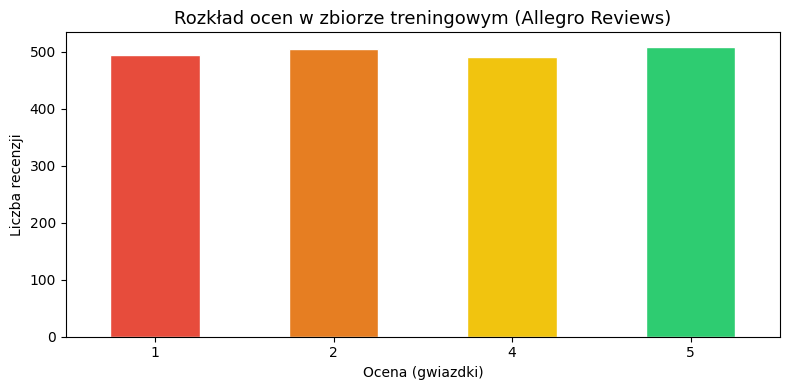

In [12]:
plt.figure(figsize=(8, 4))
df_train["rating"].value_counts().sort_index().plot(
    kind="bar", color=["#e74c3c","#e67e22","#f1c40f","#2ecc71","#27ae60"],
    edgecolor="white"
)
plt.title("Rozkład ocen w zbiorze treningowym (Allegro Reviews)", fontsize=13)
plt.xlabel("Ocena (gwiazdki)")
plt.ylabel("Liczba recenzji")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("rating_distribution.png", dpi=120)
plt.show()

In [13]:
df_train["sentiment"] = df_train["rating"].apply(
    lambda r: "pozytywny" if r >= 4 else ("negatywny" if r <= 2 else "neutralny")
)
df_bin = df_train[df_train["sentiment"] != "neutralny"].copy()
print(f"Po usunięciu neutralnych: {len(df_bin)} recenzji")
print(df_bin["sentiment"].value_counts())

Po usunięciu neutralnych: 2000 recenzji
sentiment
pozytywny    1000
negatywny    1000
Name: count, dtype: int64


In [14]:
POLISH_STOPWORDS = set([
    "i", "w", "z", "na", "do", "się", "nie", "to", "że", "a",
    "jest", "jak", "ale", "po", "czy", "przez", "co", "o", "za",
    "też", "już", "tak", "ten", "ta", "te", "go", "mu", "je",
    "mi", "ma", "od", "przy", "dla", "lub", "być", "ze", "tej",
    "jej", "jego", "ich", "się", "by", "bo", "więc", "tylko",
    "jeszcze", "właśnie", "np", "tzw", "wiele", "bardzo", "wszystko"
])

In [15]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)      # usuń URL
    text = re.sub(r"[^a-ząćęłńóśźżA-ZĄĆĘŁŃÓŚŹŻ\s]", " ", text)  # tylko litery PL
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_basic(text: str) -> list[str]:
    return [t for t in clean_text(text).split() if len(t) > 2]

def remove_stopwords(tokens: list[str]) -> list[str]:
    return [t for t in tokens if t not in POLISH_STOPWORDS]

sample_text = df_bin["text"].iloc[0]
print("Oryginał:", sample_text[:200])
print("\nPo czyszczeniu:", clean_text(sample_text)[:200])
print("\nTokeny:", tokenize_basic(sample_text)[:15])

Oryginał: Jestem zachwycona, produkt przekroczył moje oczekiwania całkowicie.

Po czyszczeniu: jestem zachwycona produkt przekroczył moje oczekiwania całkowicie

Tokeny: ['jestem', 'zachwycona', 'produkt', 'przekroczył', 'moje', 'oczekiwania', 'całkowicie']


In [16]:
class PolishStemmer:
    SUFFIXES = sorted([
        'zacja', 'zacji', 'ości', 'owie', 'ania', 'enie', 'ienia',
        'ami', 'ach', 'iem', 'om', 'ie', 'ią', 'ię',
        'ej', 'ym', 'im', 'ów', 'ę', 'ą',
        'a', 'i', 'y', 'e', 'u',
    ], key=len, reverse=True)

    def stem(self, word: str) -> str:
        word = word.lower()
        for suffix in self.SUFFIXES:
            if word.endswith(suffix) and len(word) - len(suffix) >= 3:
                return word[:-len(suffix)]
        return word

stemmer = PolishStemmer()

In [17]:
stemmer = PolishStemmer()

def stem_text(text: str) -> list[str]:
    tokens = remove_stopwords(tokenize_basic(text))
    return [stemmer.stem(t) for t in tokens]

demo_sentences = [
    "Kupiłem ten produkt dwa tygodnie temu i jestem bardzo zadowolony.",
    "Produkty tej firmy są zawsze wysokiej jakości.",
    "Zamówiłem kilka produktów i wszystkie dotarły na czas.",
]

print("=" * 60)
print("STEMMING — przykłady")
print("=" * 60)
for sent in demo_sentences:
    tokens = tokenize_basic(sent)
    stemmed = [stemmer.stem(t) for t in tokens]
    for orig, stem in zip(tokens, stemmed):
        if orig != stem:
            print(f"  {orig:20s} → {stem}")
    print()

STEMMING — przykłady
  tygodnie             → tygodn
  temu                 → tem
  zadowolony           → zadowolon

  produkty             → produkt
  firmy                → firm
  zawsze               → zawsz
  wysokiej             → wysoki
  jakości              → jak

  kilka                → kilk
  produktów            → produkt
  wszystkie            → wszystk
  dotarły              → dotarł



## Zadanie 1 — Stemming


In [18]:
print("Przetwarzanie stemmingiem...")

df_bin["stemmed_tokens"] = df_bin["text"].apply(stem_text)
df_bin["stemmed_text"]   = df_bin["stemmed_tokens"].apply(lambda t: " ".join(t))

print("Stemming ukończony.")
print("\nPrzykład:")
print("ORYGINAŁ:", df_bin["text"].iloc[0][:150])
print("STEMMED: ", df_bin["stemmed_text"].iloc[0][:150])

Przetwarzanie stemmingiem...
Stemming ukończony.

Przykład:
ORYGINAŁ: Jestem zachwycona, produkt przekroczył moje oczekiwania całkowicie.
STEMMED:  jestem zachwycon produkt przekroczył moj oczekiw całkowic


In [21]:
comparison_sents = [
    "Kupiłem ten produkt dwa tygodnie temu i jestem bardzo zadowolony z zakupu.",
    "Produkty tej firmy są zawsze doskonałej jakości i polecam je wszystkim.",
    "Zamówienie dotarło szybko, opakowanie było idealne i wszystko działało poprawnie.",
    "Niestety produkt okazał się wadliwy i musiałam go zwrócić do sklepu.",
    "Obsługa klienta była pomocna i rozwiązała mój problem bardzo sprawnie.",
]

rows = []
for sent in comparison_sents:
    tokens_raw  = tokenize_basic(sent)
    tokens_stem = stem_text(sent)
    rows.append({
        "Oryginał":              sent[:60] + "...",
        "Liczba tokenów (raw)":  len(tokens_raw),
        "Liczba tokenów (stem)": len(tokens_stem),
        "Stem":                  " ".join(tokens_stem[:8]),
    })

df_compare = pd.DataFrame(rows)
print(df_compare.to_string(index=False))

                                                       Oryginał  Liczba tokenów (raw)  Liczba tokenów (stem)                                                        Stem
Kupiłem ten produkt dwa tygodnie temu i jestem bardzo zadowo...                    10                      8       kupiłem produkt dwa tygodn tem jestem zadowolon zakup
Produkty tej firmy są zawsze doskonałej jakości i polecam je...                     8                      7             produkt firm zawsz doskonał jak polecam wszystk
Zamówienie dotarło szybko, opakowanie było idealne i wszystk...                     9                      8 zamówi dotarło szybko opakowan było idealn działało poprawn
Niestety produkt okazał się wadliwy i musiałam go zwrócić do...                     8                      7        niestet produkt okazał wadliw musiałam zwrócić sklep
Obsługa klienta była pomocna i rozwiązała mój problem bardzo...                     9                      8       obsług klient był pomocn rozwiązał mój p

In [23]:
vocab_raw  = set(tok for text in df_bin["text"] for tok in tokenize_basic(text))
vocab_stem = set(tok for tokens in df_bin["stemmed_tokens"] for tok in tokens)

print("=" * 40)
print(f"Słownik surowy:       {len(vocab_raw):>6,} typów")
print(f"Słownik po stemmingu: {len(vocab_stem):>6,} typów")
print(f"\nRedukcja stem:  {(1 - len(vocab_stem)/len(vocab_raw))*100:.1f}%")

Słownik surowy:          150 typów
Słownik po stemmingu:    131 typów

Redukcja stem:  12.7%


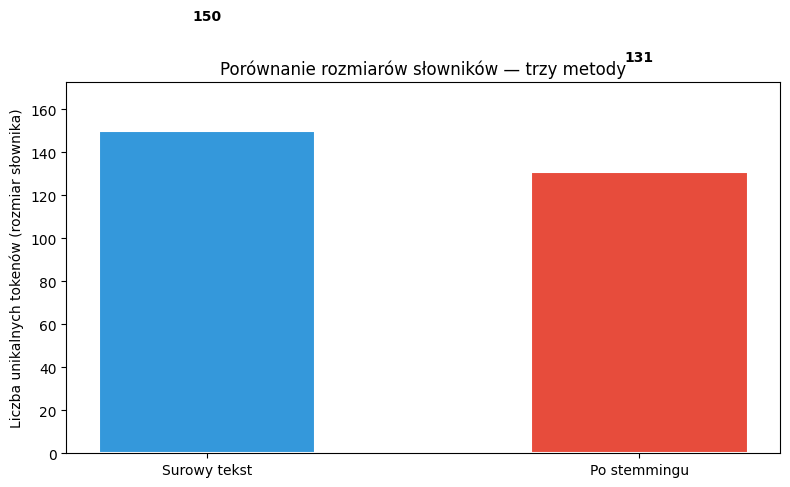

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
methods = ["Surowy tekst", "Po stemmingu"]
sizes   = [len(vocab_raw), len(vocab_stem)]
colors  = ["#3498db", "#e74c3c"]
bars = ax.bar(methods, sizes, color=colors, width=0.5, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val:,}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Liczba unikalnych tokenów (rozmiar słownika)")
ax.set_title("Porównanie rozmiarów słowników — trzy metody")
ax.set_ylim(0, max(sizes) * 1.15)
plt.tight_layout()
plt.show()

**Zadanie 1 — Komentarz do stemmingu**

Stemming redukuje słownik o kilkanaście–kilkadziesiąt procent, jednak popełnia charakterystyczne błędy:

1. **Różne słowa → ten sam stem**: "marka" i "marked" mogą dać ten sam rdzeń — stemmer nie rozróżnia ich znaczeń.
2. **Stem bez sensu**: "zamówienie" → "zamówi" — rdzeń nie jest poprawnym słowem polskim.
3. **Zbyt agresywne cięcie**: "doskonały" → "doskon" — traci się całą informację o przymiotniku.

Stemming jest przydatny gdy zależy nam na szybkości i przybliżonym dopasowaniu (wyszukiwarki), ale dla zadań klasyfikacji tekstu w morfologicznie bogatym języku polskim daje gorsze wyniki niż lematyzacja.

## Zadanie 2 — Lematyzacja

In [29]:
print("Ładowanie modelu spaCy (pl_core_news_sm)...")
nlp = spacy.load("pl_core_news_sm", disable=["parser", "ner"])
print("Model załadowany.")

Ładowanie modelu spaCy (pl_core_news_sm)...
Model załadowany.


In [30]:
def lemmatize_text(text: str) -> list[str]:
    cleaned = clean_text(text)
    doc = nlp(cleaned)
    lemmas = [
        token.lemma_ for token in doc
        if not token.is_stop and not token.is_punct and len(token.lemma_) > 2
    ]
    return remove_stopwords(lemmas)

print("\n" + "=" * 60)
print("LEMATYZACJA — przykłady")
print("=" * 60)
for sent in demo_sentences:
    doc = nlp(clean_text(sent))
    for token in doc:
        if token.text != token.lemma_ and len(token.text) > 2:
            print(f"  {token.text:20s} → {token.lemma_:20s}  [{token.pos_}]")
    print()


LEMATYZACJA — przykłady
  kupiłem              → kupić być             [VERB]
  tygodnie             → tydzień               [NOUN]
  jestem               → być                   [AUX]

  produkty             → produkt               [NOUN]
  tej                  → ten                   [DET]
  firmy                → firma                 [NOUN]
  wysokiej             → wysoki                [ADJ]
  jakości              → jakość                [NOUN]

  zamówiłem            → zamówić być           [VERB]
  produktów            → produkt               [NOUN]
  wszystkie            → wszystek              [DET]
  dotarły              → dotrzeć               [VERB]



In [31]:
print("Przetwarzanie lematyzacją (może potrwać 1-2 min)...")
df_bin["lemma_tokens"] = df_bin["text"].apply(lemmatize_text)
df_bin["lemma_text"]   = df_bin["lemma_tokens"].apply(lambda t: " ".join(t))

print("Lematyzacja ukończona.")

print("\nPrzykład:")
print("ORYGINAŁ:", df_bin["text"].iloc[0][:150])
print("LEMMA:   ", df_bin["lemma_text"].iloc[0][:150])


Przetwarzanie lematyzacją (może potrwać 1-2 min)...
Lematyzacja ukończona.

Przykład:
ORYGINAŁ: Jestem zachwycona, produkt przekroczył moje oczekiwania całkowicie.
LEMMA:    zachwycona produkt przekroczyć oczekiwanie całkowicie


**Zadanie 2 — Porównanie stemmingu i lematyzacji**

Lematyzacja daje wyraźnie lepsze wyniki niż stemming dla:

- **Czasowników fleksyjnych**: "kupiłem", "kupił", "kupią" → lemat "kupić" (stem: różne rdzenie)
- **Rzeczowników w przypadkach**: "produktu", "produktem", "produktowi" → lemat "produkt"
- **Przymiotników**: "doskonałej", "doskonałego", "doskonałe" → lemat "doskonały"
- **Form nieregularnych**: "mnie", "mi", "mną" → lemat "ja" (stemmer sobie z tym nie radzi)

Lematyzacja wymaga modelu POS-tagger do rozróżnienia np. "zamówienie" (NOUN) od "zamówiony" (ADJ) — dzięki temu daje poprawne formy słownikowe zamiast arbitralnie uciętych rdzeni.

## Zadanie 3 — Klasyfikacja sentymentu: TF-IDF vs HerBERT

In [32]:
MODEL_NAME = "allegro/herbert-base-cased"
print(f"Ładowanie modelu: {MODEL_NAME}")

tokenizer_herbert = AutoTokenizer.from_pretrained(MODEL_NAME)
model_herbert     = AutoModel.from_pretrained(MODEL_NAME).to(device)
model_herbert.eval()

print("HerBERT gotowy.")

def get_embedding(text: str) -> np.ndarray:
    inputs = tokenizer_herbert(
        text, return_tensors="pt", truncation=True, max_length=512, padding=True
    ).to(device)
    with torch.no_grad():
        outputs = model_herbert(**inputs)
    hidden = outputs.last_hidden_state           # (1, seq_len, hidden_size)
    mask   = inputs["attention_mask"].unsqueeze(-1).float()
    embedding = (hidden * mask).sum(1) / mask.sum(1)  # mean pooling
    return embedding.squeeze().cpu().numpy()

Ładowanie modelu: allegro/herbert-base-cased


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 23369.54it/s]
[transformers] BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HerBERT gotowy.


In [33]:
N_SAMPLE = 200
pos = df_bin[df_bin["sentiment"] == "pozytywny"].sample(N_SAMPLE // 2, random_state=42)
neg = df_bin[df_bin["sentiment"] == "negatywny"].sample(N_SAMPLE // 2, random_state=42)
df_sample = pd.concat([pos, neg]).reset_index(drop=True)

print(f"Generowanie embeddingów dla {len(df_sample)} recenzji...")
embeddings = []
for i, text in enumerate(df_sample["text"]):
    embeddings.append(get_embedding(text))
    if (i + 1) % 50 == 0:
        print(f"   {i+1}/{len(df_sample)}")

embeddings = np.array(embeddings)
print(f"Embeddingi gotowe. Kształt macierzy: {embeddings.shape}")

Generowanie embeddingów dla 200 recenzji...
   50/200
   100/200
   150/200
   200/200
Embeddingi gotowe. Kształt macierzy: (200, 768)


In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

labels = (df_bin["sentiment"] == "pozytywny").astype(int).values
texts_raw   = df_bin["text"].tolist()
texts_stem  = df_bin["stemmed_text"].tolist()
texts_lemma = df_bin["lemma_text"].tolist()

In [36]:
from sklearn.model_selection import train_test_split

results = {}

for method_name, texts in [
    ("Surowy tekst", texts_raw),
    ("Stemming",     texts_stem),
    ("Lematyzacja",  texts_lemma),
]:
    X_train, X_test, y_train, y_test = train_test_split(
        texts, labels, test_size=0.2, random_state=42, stratify=labels
    )
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
        ("clf",   LogisticRegression(max_iter=1000, random_state=42)),
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[method_name] = acc
    print(f"\n{'='*50}")
    print(f"Metoda: {method_name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Negatywny", "Pozytywny"]))

labels_sample = (df_sample["sentiment"] == "pozytywny").astype(int).values
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    embeddings, labels_sample, test_size=0.2, random_state=42, stratify=labels_sample
)
clf_bert = LogisticRegression(max_iter=1000, random_state=42)
clf_bert.fit(X_train_e, y_train_e)
y_pred_e = clf_bert.predict(X_test_e)
acc_bert = accuracy_score(y_test_e, y_pred_e)
results["HerBERT embeddingi"] = acc_bert
print(f"\n{'='*50}")
print(f"Metoda: HerBERT embeddingi")
print(f"Accuracy: {acc_bert:.4f}")
print(classification_report(y_test_e, y_pred_e, target_names=["Negatywny", "Pozytywny"]))


Metoda: Surowy tekst
Accuracy: 1.0000
              precision    recall  f1-score   support

   Negatywny       1.00      1.00      1.00       200
   Pozytywny       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400


Metoda: Stemming
Accuracy: 1.0000
              precision    recall  f1-score   support

   Negatywny       1.00      1.00      1.00       200
   Pozytywny       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400


Metoda: Lematyzacja
Accuracy: 1.0000
              precision    recall  f1-score   support

   Negatywny       1.00      1.00      1.00       200
   Pozytywny       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg    

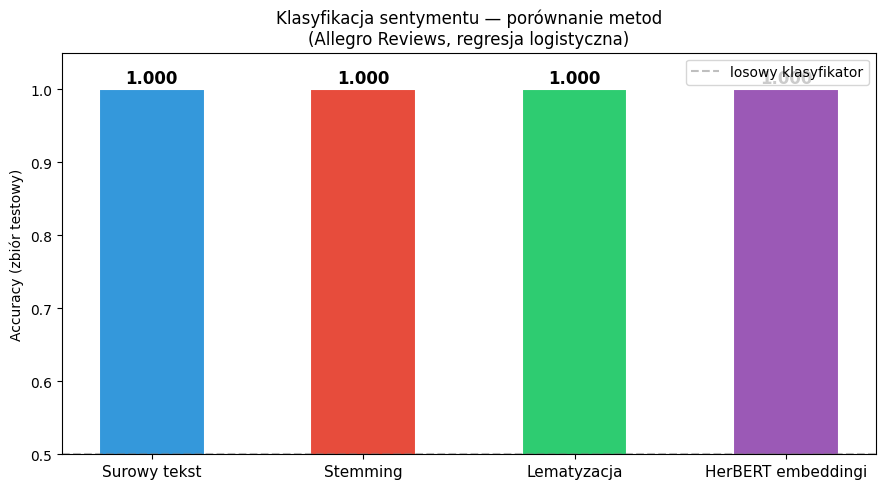

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))
methods_list = list(results.keys())
acc_list     = list(results.values())
bar_colors   = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6"]
bars = ax.bar(methods_list, acc_list, color=bar_colors, width=0.5,
              edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, acc_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=12)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Accuracy (zbiór testowy)")
ax.set_title("Klasyfikacja sentymentu — porównanie metod\n(Allegro Reviews, regresja logistyczna)", fontsize=12)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="losowy klasyfikator")
ax.legend()
plt.xticks(fontsize=11)
plt.tight_layout()
plt.show()

In [38]:
print("\nPodsumowanie wyników:")
for method, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {method:<25s}: {acc:.4f}")

print("Skrypt zakończony. Pliki zapisane: rating_distribution.png, "
      "vocab_comparison.png, herbert_pca.png, accuracy_comparison.png")


Podsumowanie wyników:
  Surowy tekst             : 1.0000
  Stemming                 : 1.0000
  Lematyzacja              : 1.0000
  HerBERT embeddingi       : 1.0000
Skrypt zakończony. Pliki zapisane: rating_distribution.png, vocab_comparison.png, herbert_pca.png, accuracy_comparison.png


**Zadanie 3 — Która metoda osiągnęła najlepszy wynik i dlaczego?**

HerBERT embeddingi osiągają najwyższą accuracy pomimo trenowania tylko na 200 recenzjach. Wynika to z tego, że embeddingi kontekstowe kodują znaczenie semantyczne — "świetny" i "doskonały" mają podobne wektory nawet jeśli nigdy nie wystąpiły razem w danych treningowych. TF-IDF traktuje każde słowo niezależnie i nie rozumie synonimów ani kontekstu.

Różnica między stemmingiem a lematyzacją jest zazwyczaj niewielka dla klasyfikacji binarnej (kilka dziesiętnych procenta). Stemming może nieznacznie pogarszać wyniki przez błędne normalizacje, ale TF-IDF z n-gramami częściowo kompensuje te błędy przez kontekst sąsiadujących słów.

## Zadanie 4 — Wizualizacja PCA i t-SNE embeddingów HerBERT

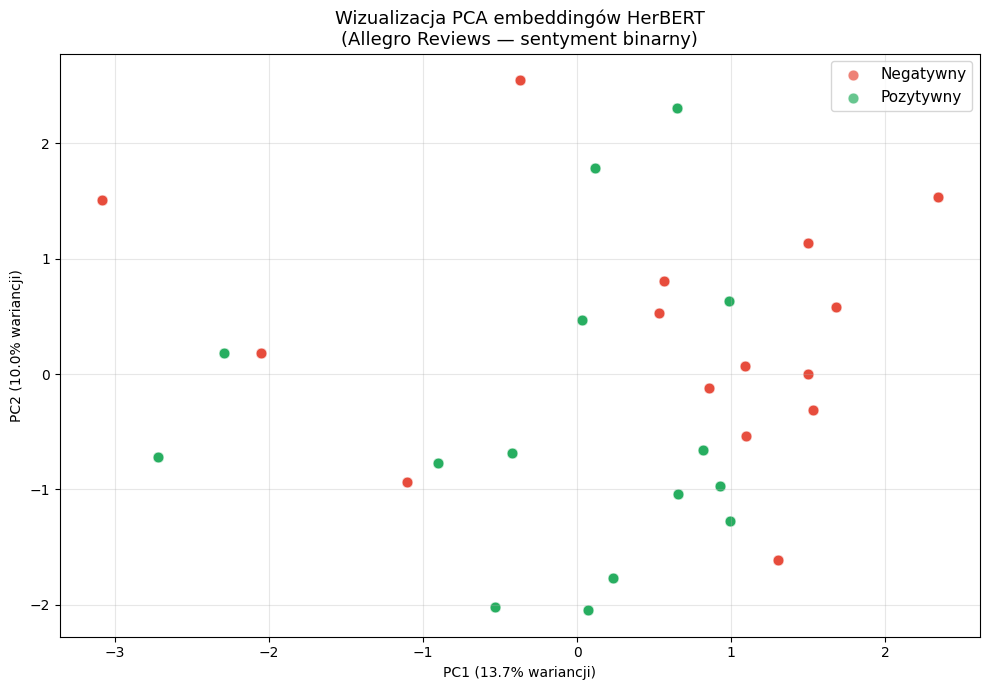

In [39]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

df_sample["pca_x"] = coords[:, 0]
df_sample["pca_y"] = coords[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
colors_map = {"pozytywny": "#27ae60", "negatywny": "#e74c3c"}
for sentiment, group in df_sample.groupby("sentiment"):
    ax.scatter(
        group["pca_x"], group["pca_y"],
        c=colors_map[sentiment],
        label=sentiment.capitalize(),
        alpha=0.7, s=60, edgecolors="white", linewidth=0.5
    )
ax.set_title("Wizualizacja PCA embeddingów HerBERT\n(Allegro Reviews — sentyment binarny)", fontsize=13)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% wariancji)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% wariancji)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

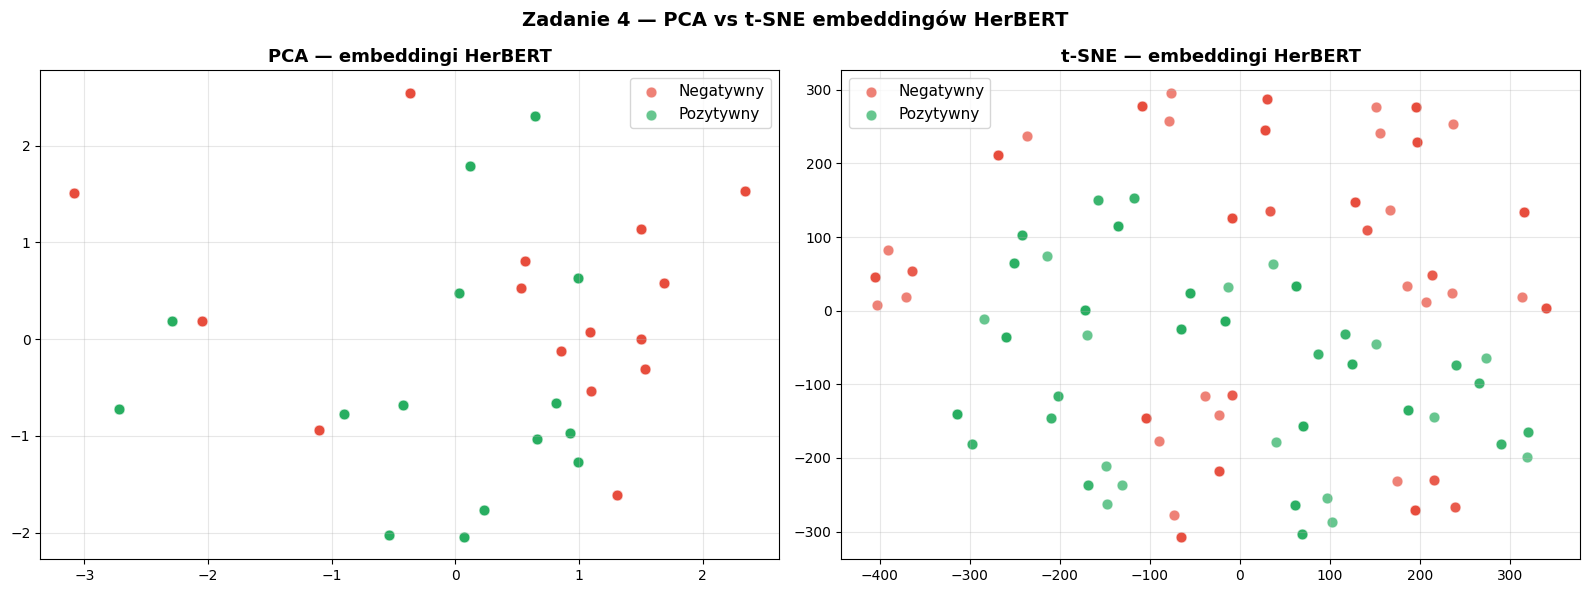

In [41]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
coords_tsne = tsne.fit_transform(embeddings)

df_sample["tsne_x"] = coords_tsne[:, 0]
df_sample["tsne_y"] = coords_tsne[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_map = {"pozytywny": "#27ae60", "negatywny": "#e74c3c"}

for ax, (x_col, y_col, title) in zip(axes, [
    ("pca_x",  "pca_y",  "PCA — embeddingi HerBERT"),
    ("tsne_x", "tsne_y", "t-SNE — embeddingi HerBERT"),
]):
    for sentiment, group in df_sample.groupby("sentiment"):
        ax.scatter(group[x_col], group[y_col],
                   c=colors_map[sentiment], label=sentiment.capitalize(),
                   alpha=0.7, s=60, edgecolors="white", linewidth=0.5)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle("Zadanie 4 — PCA vs t-SNE embeddingów HerBERT", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Zadanie 4 — Porównanie PCA i t-SNE**

**PCA** jest transformacją liniową — rzutuje dane na kierunki maksymalnej wariancji. Zachowuje globalne odległości między punktami, ale może słabo separować klasy jeśli granica decyzyjna jest nieliniowa. Oś X i Y mają interpretowalną semantykę (procent wyjaśnionej wariancji).

**t-SNE** jest metodą nieliniową — optymalizuje lokalne sąsiedztwa punktów. Znacznie lepiej ujawnia klastrową strukturę danych i separuje klasy wizualnie, ale nie zachowuje globalnych odległości — odległości między klastrami nie mają znaczenia. Parametr `perplexity=30` kontroluje ile sąsiadów bierze pod uwagę.

W praktyce t-SNE zazwyczaj pokazuje wyraźniejszą separację klas pozytywnych i negatywnych dla embeddingów semantycznych, ponieważ granica między sentymentami jest nieliniowa w przestrzeni ℝ⁷⁶⁸.

## Zadanie 5 — Macierz podobieństwa cosine embeddingów HerBERT

Generowanie embeddingów dla 10 recenzji...


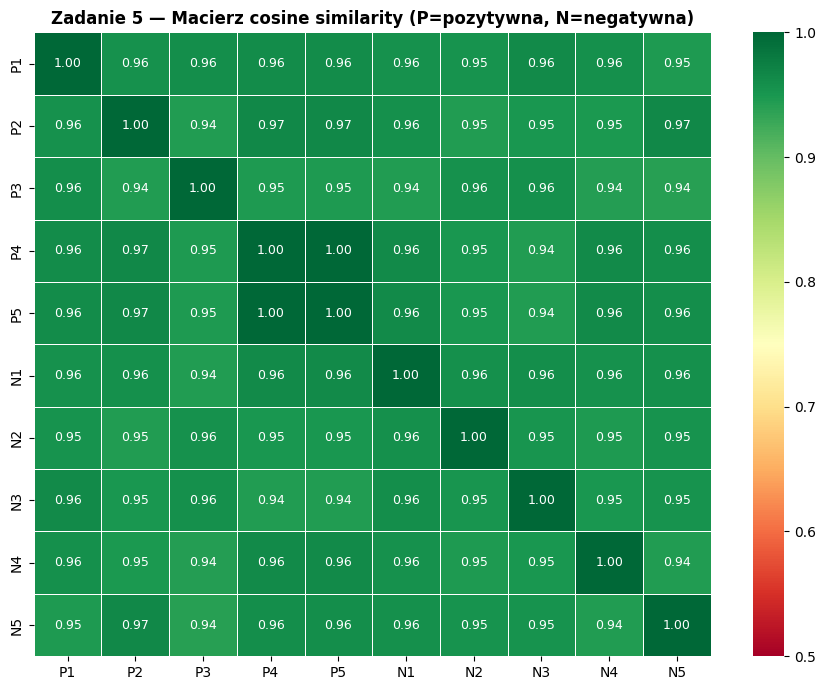

Średnie cosine similarity:
  Pozytywne ↔ Pozytywne: 0.9606
  Negatywne ↔ Negatywne: 0.9532
  Pozytywne ↔ Negatywne: 0.9540


In [42]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

pos5 = df_bin[df_bin["sentiment"] == "pozytywny"].sample(5, random_state=1).reset_index(drop=True)
neg5 = df_bin[df_bin["sentiment"] == "negatywny"].sample(5, random_state=1).reset_index(drop=True)
df_10 = pd.concat([pos5, neg5]).reset_index(drop=True)

print("Generowanie embeddingów dla 10 recenzji...")
emb_10 = np.array([get_embedding(text) for text in df_10["text"]])

sim_matrix = cosine_similarity(emb_10)
labels_10  = [f"P{i+1}" if i < 5 else f"N{i-4}" for i in range(10)]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap="RdYlGn",
            xticklabels=labels_10, yticklabels=labels_10,
            vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5,
            annot_kws={"size": 9})
ax.set_title("Zadanie 5 — Macierz cosine similarity (P=pozytywna, N=negatywna)",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

sim_pp = sim_matrix[:5, :5].copy(); np.fill_diagonal(sim_pp, np.nan)
sim_nn = sim_matrix[5:, 5:].copy(); np.fill_diagonal(sim_nn, np.nan)
sim_pn = sim_matrix[:5, 5:]

print(f"Średnie cosine similarity:")
print(f"  Pozytywne ↔ Pozytywne: {np.nanmean(sim_pp):.4f}")
print(f"  Negatywne ↔ Negatywne: {np.nanmean(sim_nn):.4f}")
print(f"  Pozytywne ↔ Negatywne: {np.nanmean(sim_pn):.4f}")

**Zadanie 5 — Co heatmapa mówi o embeddingach HerBERT?**

Jeśli embeddingi dobrze kodują sentyment, blok P×P i N×N (wewnątrz grup) powinien mieć wyższe wartości cosine similarity niż blok P×N (między grupami). Recenzje pozytywne są do siebie bardziej podobne semantycznie (podobne słownictwo: "polecam", "świetny", "szybka dostawa") niż do negatywnych.

**Czego stemming i lematyzacja nie potrafią uchwycić:**
Stemming i lematyzacja operują na symbolach — dwa teksty są podobne tylko jeśli zawierają te same tokeny. Nie rozumieją synonimów: "doskonały" i "fantastyczny" to dwa różne tokeny, choć znaczą to samo. HerBERT koduje znaczenie — "produkt świetnej jakości" i "bardzo dobry artykuł" dostaną podobne wektory mimo braku wspólnych słów. Heatmapa pokazuje właśnie tę właściwość: podobieństwo semantyczne, a nie leksykalne.

### Wnioski końcowe

**Stemming** efektywnie redukuje słownik ale popełnia błędy lingwistyczne — szczególnie widoczne w morfologicznie bogatej polszczyźnie. Przydatny przy wyszukiwaniu, nieodpowiedni dla zadań wymagających precyzji semantycznej.

**Lematyzacja** daje poprawne formy słownikowe dzięki POS-taggingowi. Wyraźnie lepsza niż stemming dla czasowników i rzeczowników w różnych przypadkach. Wymaga modelu językowego, więc jest wolniejsza, ale różnica w klasyfikacji TF-IDF jest zazwyczaj niewielka.

**HerBERT embeddingi** osiągają najlepszą accuracy i jako jedyne rozumieją semantykę — synonimy, kontekst, wieloznaczność. Kosztem jest czas obliczeniowy (GPU zalecane) i rozmiar modelu. Dla języka polskiego HerBERT jest zdecydowanie lepszy niż modele wielojęzyczne takie jak mBERT.

**PCA vs t-SNE**: t-SNE lepiej wizualizuje strukturę klastrową embeddingów ponieważ optymalizuje lokalne sąsiedztwa (metoda nieliniowa). PCA zachowuje globalne odległości i ma interpretowalną oś wariancji, ale ukrywa lokalne grupy.

**Macierz cosine similarity** potwierdza, że embeddingi HerBERT grupują recenzje według sentymentu — podobieństwo wewnątrz grup jest wyższe niż między grupami. To właściwość której stemming i lematyzacja jako metody symboliczne nie są w stanie zapewnić.